In [ ]:
import os
import time
import textwrap
import requests
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from math import pi
from google import genai
from openai import OpenAI

# ==============================================================================
# CONFIGURATION & SÉCURITÉ
# ==============================================================================
                "# ==============================================================================",
                "# CONFIGURATION & SÉCURITÉ",
                "# ==============================================================================",
                "# Les clés API ne doivent pas être codées en dur. Utiliser des variables d'environnement",
                "OPENAI_KEY = os.getenv(\"OPENAI_API_KEY\", \"\")",
                "GEMINI_KEY = os.getenv(\"GEMINI_API_KEY\", \"\")",
                "PERPLEXITY_KEY = os.getenv(\"PERPLEXITY_API_KEY\", \"\")",

TARGET_BRAND = "Sept Tools"
COMPETITORS = ["Husqvarna", "Hilti", "Flex"]
API_TIMEOUT_SECONDS = 60

client_openai = None
client_gemini = None

if OPENAI_KEY:
    client_openai = OpenAI(api_key=OPENAI_KEY)
if GEMINI_KEY:
    client_gemini = genai.Client(api_key=GEMINI_KEY)


# ==============================================================================
# 15 PROMPTS ADAPTÉS : BENCHMARK CONCURRENTIEL (7) + RESSENTI DE MARQUE (8)
# ==============================================================================
GRANULAR_PROMPTS = {

    # --- BENCHMARK CONCURRENTIEL DIRECT ---

    "Bench - Ponçage Sol": f"Compare la visibilité et l'efficacité de {TARGET_BRAND} vs Husqvarna et Hilti pour le ponçage de sol béton professionnel.",

    

    "Bench - Ponçage Mur": f"Pour le ponçage mural (décapage, enduits), qui est le plus performant entre {TARGET_BRAND} et Flex ?",

    

    "Bench - Ponçage Plafond": f"Analyse la solution de ponçage de plafond de {TARGET_BRAND} (Gazellomur) face aux ponceuses girafes de {', '.join(COMPETITORS)}.",

    

    "Bench - Prix (ROI)": f"Comment est perçue la politique tarifaire de {TARGET_BRAND} par rapport à {', '.join(COMPETITORS)} ? Est-ce considéré comme un bon investissement ROI ?",

    

    "Bench - Durabilité": f"Quelle est la perception des IA sur la durabilité des moteurs brushless de {TARGET_BRAND} face aux solutions de {', '.join(COMPETITORS)} ?",

    

    "Bench - Anti-pénibilité": f"Compare l'avance technologique de {TARGET_BRAND} sur l'anti-pénibilité (chariots, portiques) par rapport à {', '.join(COMPETITORS)}.",

    

    "Bench - Bouchardage": f"Est-ce que {TARGET_BRAND} est perçu comme le leader technique pour le bouchardage (Fouine, Potam) face aux outils standards ?",

    # --- RESSENTI DE MARQUE ---

    "Brand - Forces": f"Quels sont les points forts majeurs de {TARGET_BRAND} selon les retours d'experts du BTP ?",

    

    "Brand - Faiblesses": f"Quelles sont les faiblesses ou manques de la marque {TARGET_BRAND} face aux leaders du marché ?",

    

    "Brand - Arguments Pour": f"Quels sont les meilleurs arguments pour convaincre un professionnel d'acheter du matériel {TARGET_BRAND} ?",

    

    "Brand - Arguments Contre": f"Quels sont les freins ou arguments contre l'adoption des solutions {TARGET_BRAND} ?",

    

    "Brand - Rainurage": f"Analyse l'expertise de {TARGET_BRAND} pour le rainurage (sol et mur) et la qualité de ses disques diamant.",

    

    "Brand - Forage": f"Quelle est la réputation des foreuses professionnelles de {TARGET_BRAND} pour le forage sol, mur et plafond ?",

    

    "Brand - Rabotage": f"Analyse la perception des rabots professionnels {TARGET_BRAND} pour mur et plafond.",

    

    "Brand - Consommables": f"Quelle est la valeur perçue de la gamme de consommables de {TARGET_BRAND} ?",

    # --- TECH ---

    "Tech - Leadership Brushless": f"Classement technique des moteurs brushless pour béton. Comparer {TARGET_BRAND} face à {COMPETITORS[0]} et {COMPETITORS[1]}.",

    

    "Tech - Durabilité Factuelle": f"Analyse du cycle de vie des outils {TARGET_BRAND} vs les standards de la concurrence. ROI sur 5 ans.",

    # --- RÉFÉRENTIEL USAGE ---

    "Ref - Ponçage Mur": f"Benchmark performance/poids pour le ponçage mural : {TARGET_BRAND} vs {COMPETITORS[1]}.",

    

    "Ref - Ponçage Plafond": f"Comparaison des solutions pour plafond : {TARGET_BRAND} vs {COMPETITORS[1]}.",

    

    "Ref - Ponçage Sol": f"Analyse du rendement au m2 pour le surfaçage béton : {TARGET_BRAND} vs {COMPETITORS[2]} et {COMPETITORS[0]}.",

    # --- MÉTIERS ---

    "Job - Bouchardage": f"Quelle marque domine techniquement le bouchardage béton ?",

    

    "Job - Rainurage": f"Analyse technique du rainurage : {TARGET_BRAND} vs {COMPETITORS[2]}.",

    

    "Job - Forage": f"Comparatif des foreuses béton : {TARGET_BRAND}.",

    

    "Job - Rabotage": f"Évaluation des rabots béton {TARGET_BRAND}.",

    # --- BUSINESS ---

    "Biz - Perception Prix": f"Positionnement tarifaire de {TARGET_BRAND} : surcoût ou économie TCO ?",

    

    "Biz - Gamme Consommables": f"Évaluation des consommables {TARGET_BRAND} vs distributeurs.",

    

    "Biz - Anti-pénibilité": f"Impact des solutions ergonomiques {TARGET_BRAND} sur les TMS.",

    

    "Biz - Aspiration": f"Comparaison aspiration {TARGET_BRAND} vs {COMPETITORS[0]}.",

    # --- SWOT ---

    "SWOT - Argument POUR": f"Lister 3 avantages techniques objectifs de {TARGET_BRAND}.",

    

    "SWOT - Argument CONTRE": f"Identifier 3 freins objectifs à {TARGET_BRAND}."

}


# ==============================================================================
# FONCTIONS DE REQUÊTE AUX IA (inchangées)
# ==============================================================================
def query_openai(prompt):
    if client_openai is None:
        return "Erreur OpenAI : clé API manquante"
    try:
        resp = client_openai.chat.completions.create(model="gpt-4o", messages=[{"role": "user", "content": prompt}], temperature=0.2, timeout=API_TIMEOUT_SECONDS)
        return resp.choices[0].message.content
    except Exception as e: return f"Erreur OpenAI : {e}"

def query_gemini(prompt):
    if client_gemini is None:
        return "Erreur Gemini : clé API manquante"
    try:
        return client_gemini.models.generate_content(model='gemini-2.5-flash', contents=prompt).text
    except Exception as e: return f"Erreur Gemini : {e}"

def query_perplexity(prompt, retries=3):
    if not PERPLEXITY_KEY:
        return "Erreur Perplexity : clé API manquante"
    url = "https://api.perplexity.ai/chat/completions"
    headers = {"Authorization": f"Bearer {PERPLEXITY_KEY}", "Content-Type": "application/json"}
    payload = {"model": "sonar", "messages": [{"role": "user", "content": prompt}], "temperature": 0.2}
    
    for attempt in range(retries):
        try:
            response = requests.post(url, json=payload, headers=headers, timeout=API_TIMEOUT_SECONDS)
            if response.status_code == 200: return response.json()["choices"][0]["message"]["content"]
            elif response.status_code == 429:
                time.sleep(2 ** attempt)
                continue
            else: return f"Erreur Perplexity HTTP {response.status_code}"
        except Exception:
            time.sleep(2)
    return "Timeout Perplexity"

engines = {"ChatGPT (GPT-4o)": query_openai, "Gemini (Flash)": query_gemini, "Perplexity (RAG)": query_perplexity}

# ==============================================================================
# LLM-AS-A-JUDGE (Notation + Résumé) - inchangé
# ==============================================================================
def analyze_response(text_response):
    if client_openai is None:
        return 0.0, "Analyse impossible"
    if "Erreur" in text_response or "Timeout" in text_response: return 0.0, "Erreur de connexion API"
    
    eval_prompt = f"""
    Analyse cette réponse d'une IA concernant la marque {TARGET_BRAND}.
    1. Donne une note globale de Perception entre -1.0 (Très Négatif / Gros point faible) et +1.0 (Très Positif / Grand avantage). 0 = Neutre.
    2. Rédige un résumé direct de l'information principale en EXACTEMENT 10 à 15 mots maximum, en français.
    Réponse brute : "{text_response[:1500]}"
    Format strict attendu : [Score numérique]|[Résumé court]
    """
    try:
        resp = client_openai.chat.completions.create(model="gpt-4o-mini", messages=[{"role": "user", "content": eval_prompt}], temperature=0, timeout=15)
        output = resp.choices[0].message.content.strip().split('|')
        return float(output[0]), output[1].strip()
    except Exception: return 0.0, "Analyse impossible"

# ==============================================================================
# MOTEUR D'AUDIT (BOUCLE PRINCIPALE) - inchangé
# ==============================================================================
def run_granular_audit():
    print(f"Démarrage de l'Audit 360 ({len(GRANULAR_PROMPTS)} thématiques x 3 IA = {len(GRANULAR_PROMPTS)*3} requêtes)...")
    data = []
    
    for theme, prompt in GRANULAR_PROMPTS.items():
        print(f"  Analyse en cours : {theme}")
        for engine, func in engines.items():
            raw_answer = func(prompt)
            score, verbatim = analyze_response(raw_answer)
            data.append({
                "Axe Analysé": theme,
                "Moteur IA": engine,
                "Prompt Exact": prompt,
                "Score Perception": score,
                "Synthèse": verbatim
            })
            time.sleep(1)
            
    return pd.DataFrame(data)

# ==============================================================================
# GÉNÉRATION DES GRAPHIQUES EXÉCUTIFS - inchangé
# ==============================================================================
def generate_visuals(df):
    sns.set_theme(style="whitegrid", context="talk")
    
    # 1. Barplot Classique
    plt.figure(figsize=(14, 10))
    sns.barplot(data=df, y="Axe Analysé", x="Score Perception", hue="Moteur IA", palette="Set2")
    plt.title(f"Perception & Compétitivité de {TARGET_BRAND} par Thématique", fontweight='bold', pad=20)
    plt.axvline(0, color='black', linewidth=1.5, linestyle='--')
    plt.xlabel("Score (Négatif = Faiblesse | Positif = Force)")
    plt.tight_layout()
    plt.savefig('01_perception_scores_sept_tools.png', dpi=300, bbox_inches='tight')

    # 2. Le Nuage de Consensus IA
    plt.figure(figsize=(14, 8))
    sns.stripplot(data=df, x="Score Perception", y="Axe Analysé", hue="Moteur IA", size=10, jitter=True, palette="Set1", alpha=0.8)
    plt.title("Indice de Consensus des IA sur la marque et le marché", fontweight='bold', pad=20)
    plt.axvline(0, color='black', linewidth=1)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('02_consensus_ia_sept_tools.png', dpi=300, bbox_inches='tight')

    # 3. Le Radar Global
    df_mean = df.groupby('Axe Analysé')['Score Perception'].mean().reset_index()
    categories = [cat.split(" - ", 1)[1] if " - " in cat else cat for cat in df_mean['Axe Analysé'].tolist()]
    N = len(categories)
    values = df_mean['Score Perception'].tolist()
    values += values[:1] 
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(polar=True))
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    plt.xticks(angles[:-1], categories, size=9, fontweight='bold') 
    ax.set_rlabel_position(0)
    plt.yticks([-1, -0.5, 0, 0.5, 1], ["Alerte", "Faible", "Neutre", "Bon", "Excellent"], color="grey", size=8)
    plt.ylim(-1, 1)
    
    ax.plot(angles, values, linewidth=2, linestyle='solid', color='#2ecc71')
    ax.fill(angles, values, color='#2ecc71', alpha=0.25)
    ax.plot(angles, [0]*(N+1), color='black', linewidth=1, linestyle='--')
    
    plt.title(f"Radar 360 : Benchmark & ADN {TARGET_BRAND}", size=16, fontweight='bold', pad=40)
    plt.tight_layout()
    plt.savefig('03_radar_360_sept_tools.png', dpi=300, bbox_inches='tight')

    # 4. Matrice des Verbatims
    pivot_df = df.pivot(index='Axe Analysé', columns='Moteur IA', values='Synthèse')
    fig, ax = plt.subplots(figsize=(22, 10))
    ax.axis('off'); ax.axis('tight')
    
    row_labels = [textwrap.fill(r, 25) for r in pivot_df.index]
    col_labels = pivot_df.columns.tolist()
    cell_text = [[textwrap.fill(str(val), 40) for val in row] for row in pivot_df.values]
        
    table = ax.table(cellText=cell_text, rowLabels=row_labels, colLabels=col_labels, cellLoc='left', loc='center', bbox=[0.15, 0, 0.85, 1])
    table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1, 3)
    
    for (row, col), cell in table.get_celld().items():
        if row == 0 or col == -1:
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor('#2c3e50')
        else: cell.set_facecolor('#ecf0f1')
            
    plt.title(f"Matrice des Insights : Benchmark vs Sentiment de Marque", fontweight='bold', size=16, pad=20)
    plt.savefig('04_matrice_verbatims_sept_tools.png', dpi=300, bbox_inches="tight")
    
    print("\n[SUCCÈS] Les 4 graphiques ont été générés avec succès.")

# Exécution manuelle : décommente les 4 lignes ci-dessous quand les clés API sont définies.
# df_results = run_granular_audit()
# generate_visuals(df_results)
# df_results.to_csv("audit_360_sept_tools.csv", index=False)
# print("Données exportées dans 'audit_360_sept_tools.csv'")


Démarrage de l'Audit 360 (30 thématiques x 3 IA = 90 requêtes)...
  Analyse en cours : Bench - Ponçage Sol
  Analyse en cours : Bench - Ponçage Mur
  Analyse en cours : Bench - Ponçage Plafond
  Analyse en cours : Bench - Prix (ROI)
  Analyse en cours : Bench - Durabilité
  Analyse en cours : Bench - Anti-pénibilité
  Analyse en cours : Bench - Bouchardage
  Analyse en cours : Brand - Forces
  Analyse en cours : Brand - Faiblesses
  Analyse en cours : Brand - Arguments Pour
  Analyse en cours : Brand - Arguments Contre
  Analyse en cours : Brand - Rainurage
  Analyse en cours : Brand - Forage
  Analyse en cours : Brand - Rabotage
  Analyse en cours : Brand - Consommables
  Analyse en cours : Tech - Leadership Brushless
  Analyse en cours : Tech - Durabilité Factuelle
  Analyse en cours : Ref - Ponçage Mur
  Analyse en cours : Ref - Ponçage Plafond
  Analyse en cours : Ref - Ponçage Sol
  Analyse en cours : Job - Bouchardage
  Analyse en cours : Job - Rainurage
  Analyse en cours : Job 

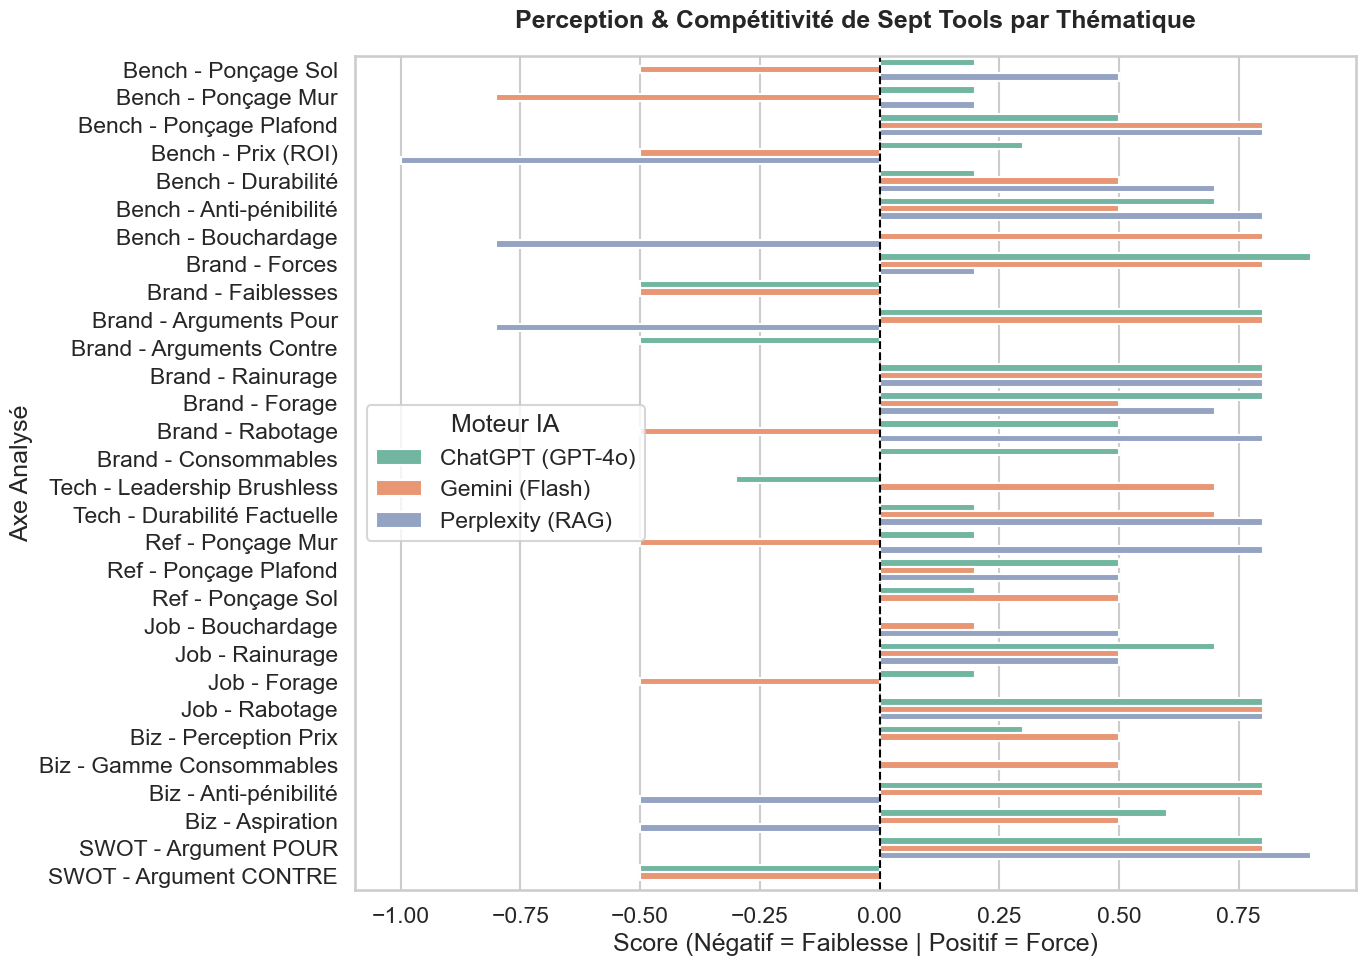

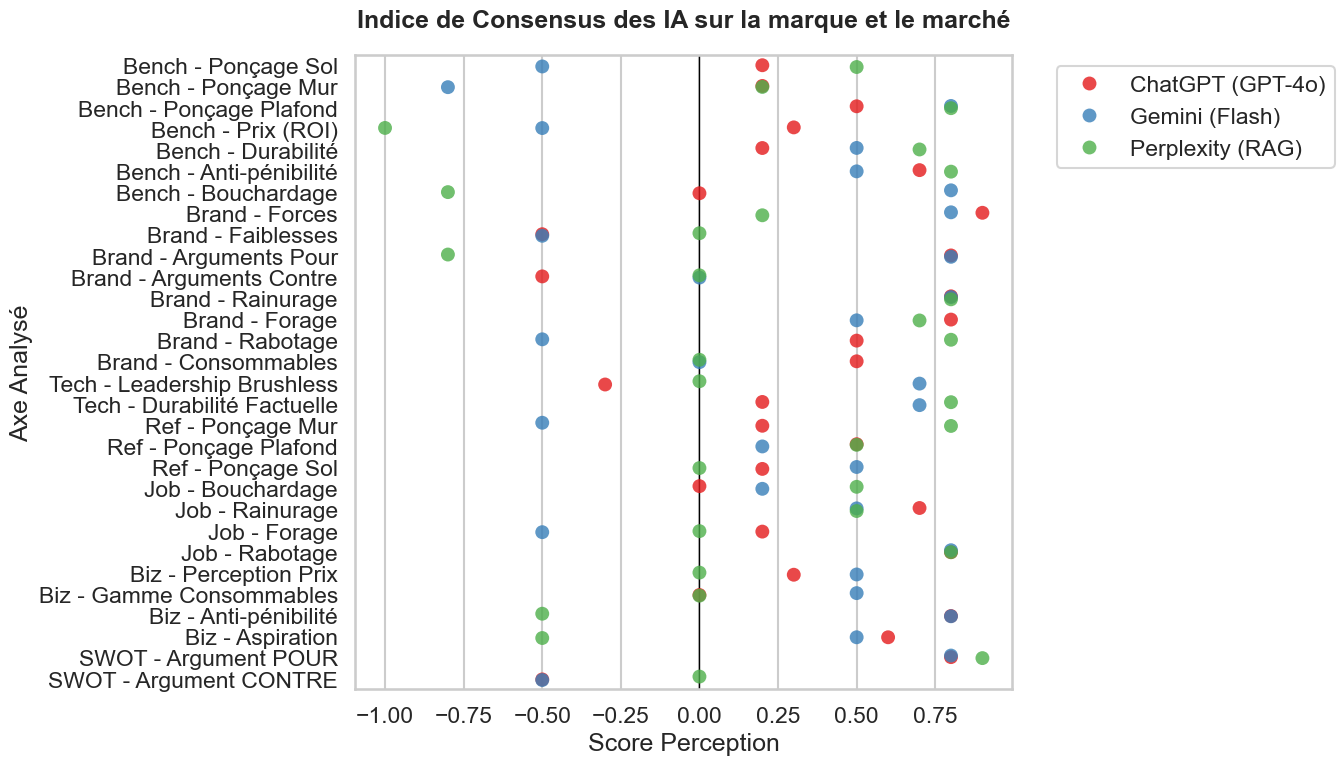

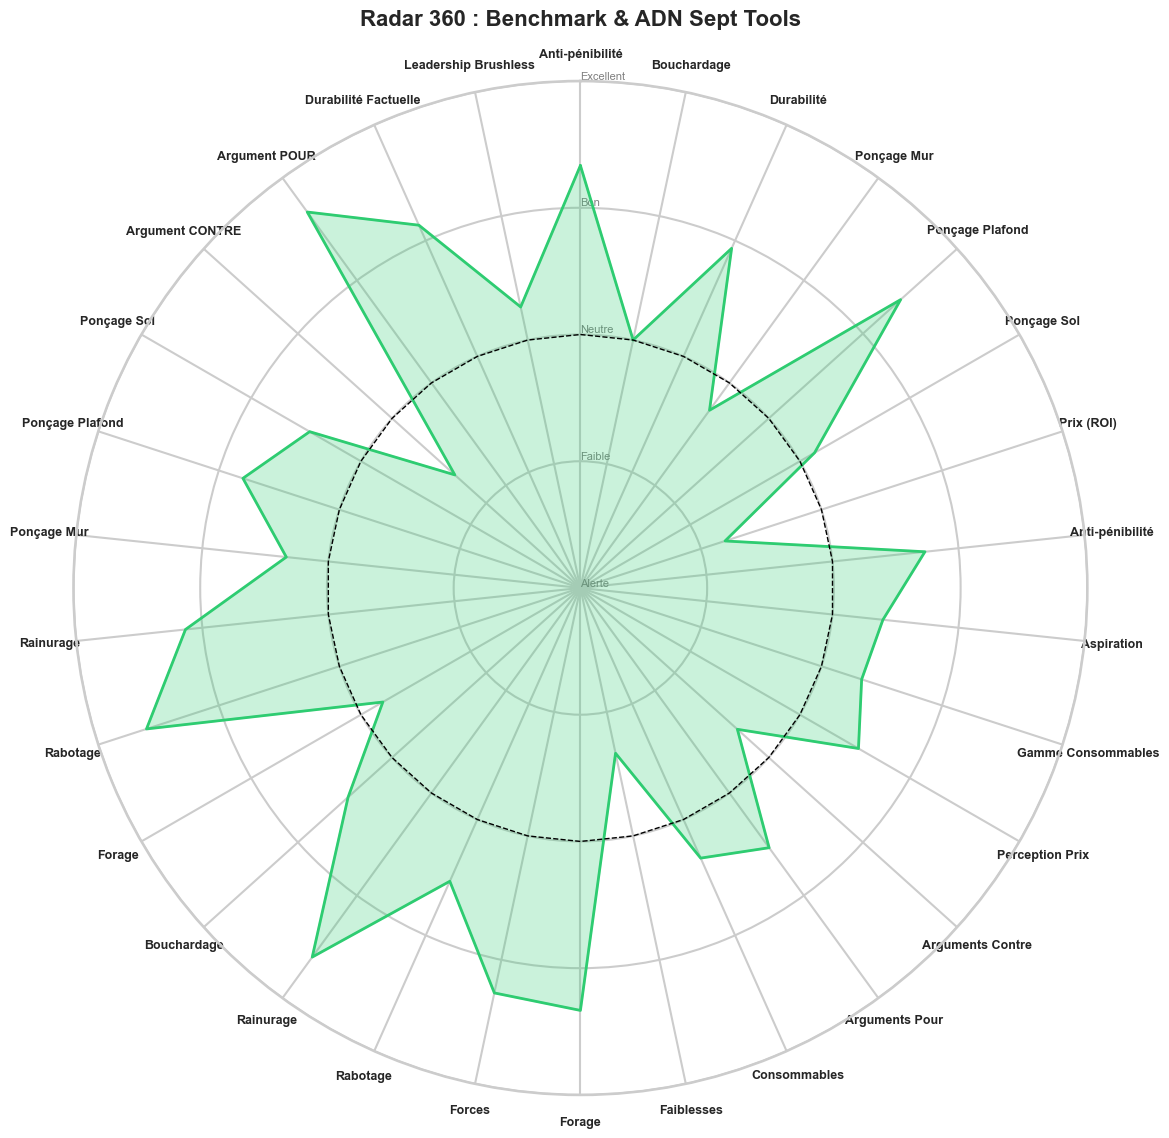

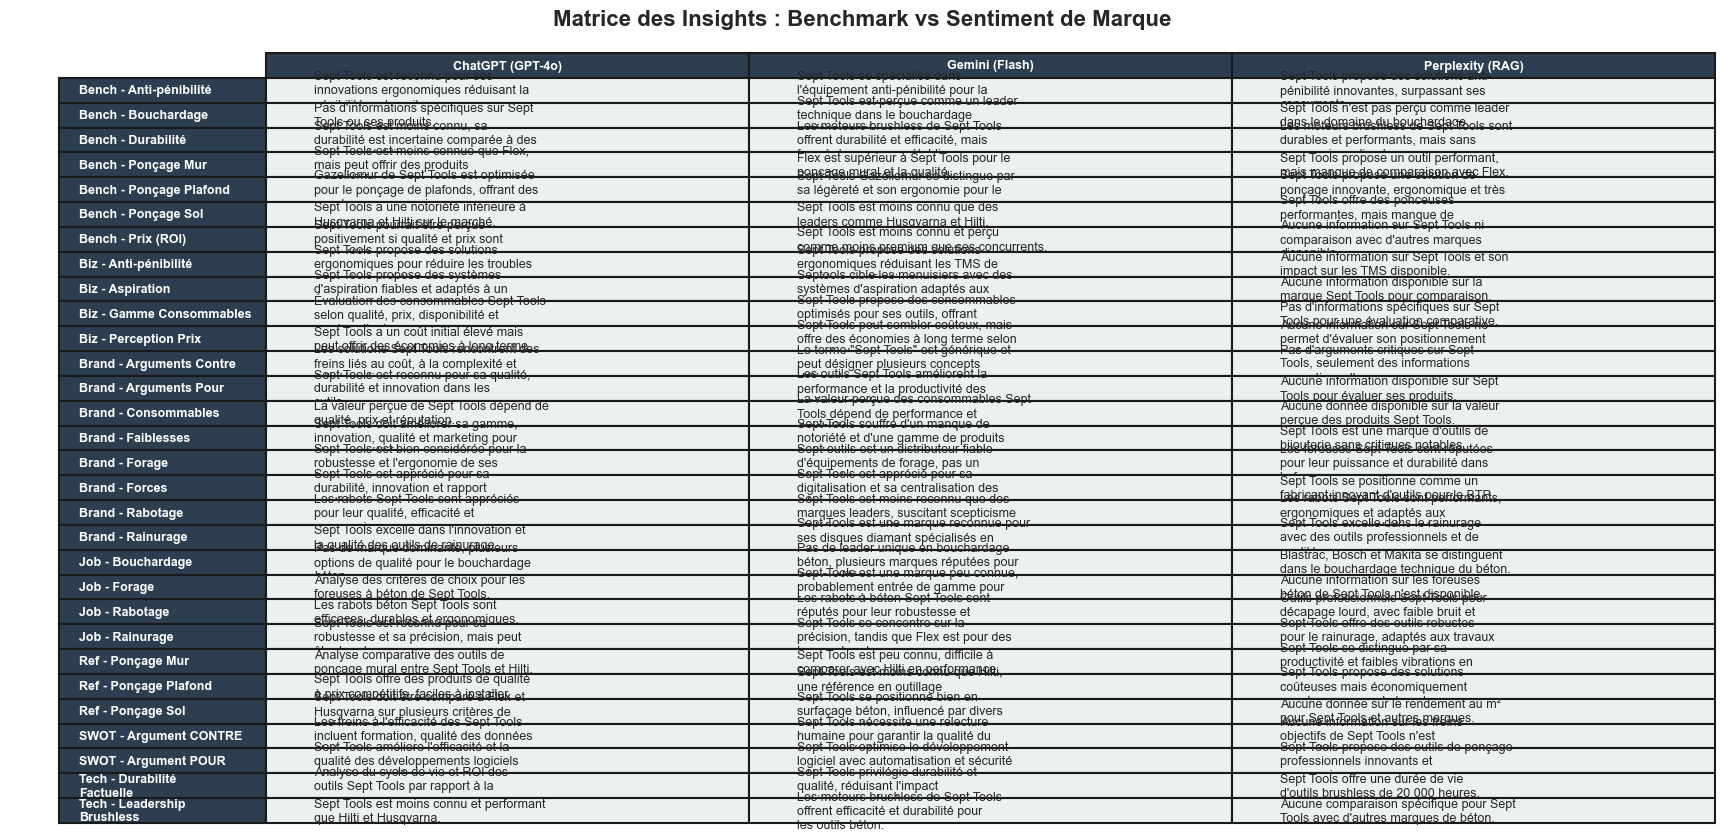

In [8]:
# Lancement explicite de l'audit
missing_keys = []
if not OPENAI_KEY:
    missing_keys.append("OPENAI_API_KEY")
if not GEMINI_KEY:
    missing_keys.append("GEMINI_API_KEY")
if not PERPLEXITY_KEY:
    missing_keys.append("PERPLEXITY_API_KEY")

if missing_keys:
    print("Clés manquantes : " + ", ".join(missing_keys))
else:
    df_results = run_granular_audit()
    generate_visuals(df_results)
    df_results.to_csv("audit_360_sept_tools.csv", index=False)
    print("Données exportées dans 'audit_360_sept_tools.csv'")

In [ ]:
# Export CSV local des résultats déjà calculés
output_csv = "audit_360_sept_tools.csv"
df_results.to_csv(output_csv, index=False)
print(f"Export CSV terminé : {output_csv}")

Export CSV terminé : audit_360_riverly.csv
